In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
# Lecture du tableau de données
data_df = pd.read_csv('../02_data/25-07-30_data_preliminary.csv')
display(data_df.head(5))
print(len(data_df))

,sp,name,hauteur,largeur,disease,mean_blue,mean_green,mean_red,nb_pixel
0,Apple,0055dd26-23a7-4415-ac61-e0b44ebfaf80___RS_HL 5...,256,256,NaN,116.747635,125.444397,128.716827,65536
1,Apple,00907d8b-6ae6-4306-bfd7-d54471981a86___RS_HL 5...,256,256,NaN,108.246124,115.296997,113.899582,65536
2,Apple,00907d8b-6ae6-4306-bfd7-d54471981a86___RS_HL 5...,256,256,NaN,108.248688,115.299789,113.902466,65536
3,Apple,0098dbd9-286a-4d6a-bf4b-5459d66f88c0___RS_HL 5...,256,256,NaN,94.179733,101.204590,104.898819,65536
4,Apple,00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7...,256,256,NaN,134.359329,129.354050,123.693680,65536


100950


In [12]:
## Vérification des doublons
data_df["id"] = data_df.sp.astype(str) + data_df.name.astype(str)
print(f"Il y a {data_df.id.duplicated().sum()} doublon(s).")

Il y a 0 doublon(s).


# Représentations graphiques

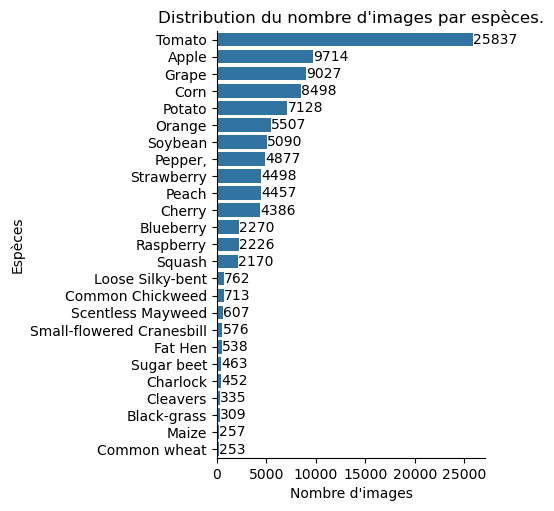

In [16]:
## Distribution des images (saines ou non)
order_distribution = data_df['sp'].value_counts().index
counts = data_df['sp'].value_counts().values
sns.catplot(data = data_df, y = 'sp', kind = 'count', order = order_distribution)
for count, sp in zip(counts, order_distribution): # Annotation du nombre d'image pour chaque espèce
    plt.annotate(str(count), 
                 xy = ((count + 1), sp),
                 va = 'center')
plt.xlabel("Nombre d'images")
plt.ylabel("Espèces")
plt.title("Distribution du nombre d'images par espèces.")
plt.show();

Il y a une sur représentation de la tomate par rapport aux autres et une sous-représentaiton de plusieurs espèces. Il y aura donc du traitement par oversampling ou de l'élimination de classes.

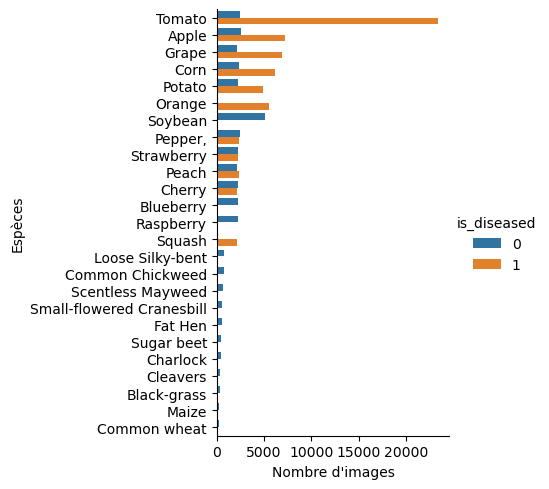

In [ ]:
## Distribution des images
data_df['is_diseased'] = data_df['disease'].notna().astype(int)
order_distribution = data_df['sp'].value_counts().index
counts = data_df['sp'].value_counts().values
sns.catplot(data = data_df, y = 'sp', kind = 'count', order = order_distribution, hue = 'is_diseased')
plt.xlabel("Nombre d'images")
plt.ylabel("Espèces")
plt.show();

On peut également voir une certaine disparité entre le nombre de photos d'individus sains et malades.

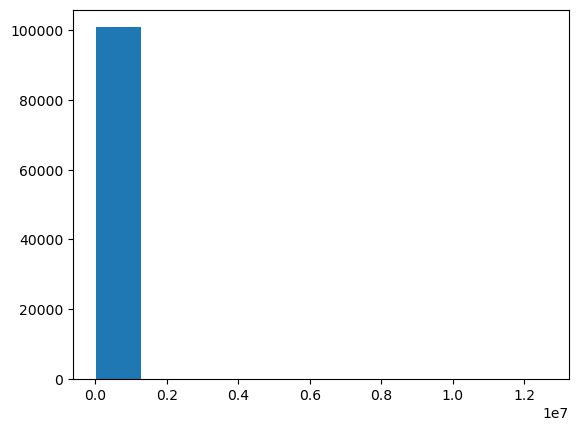

Environs 94.79% des images font le même nombre de pixels, à savoir 65536 pixels. 


In [11]:
## Distribution des tailles
plt.hist(data = data_df, x = 'nb_pixel')
plt.show();
data_df.nb_pixel.value_counts(normalize = True)

print(f"Environs {round(data_df.nb_pixel.value_counts(normalize = True).values[0]*100, 2)}% des images font le même nombre de pixels, à savoir {data_df.nb_pixel.value_counts(normalize = True).index[0]} pixels. ")

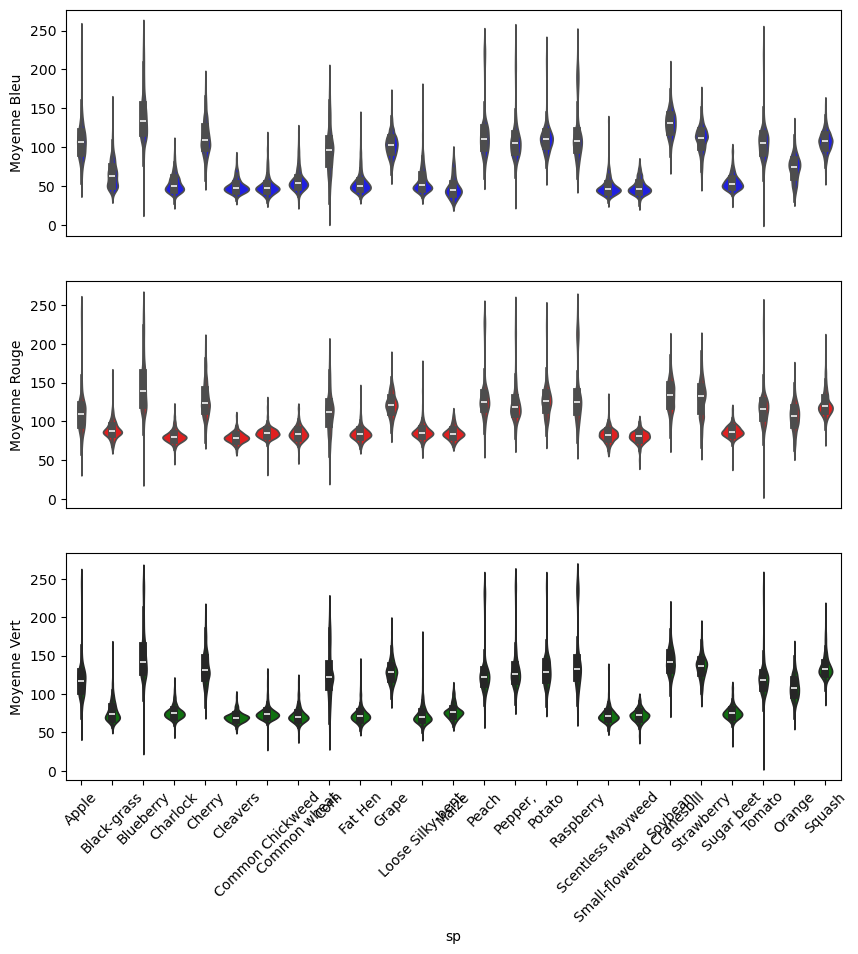

In [14]:
## Moyenne BRG
fig = plt.figure(figsize=(10,10))

plt.subplot(311)
sns.violinplot(data = data_df, y = "mean_blue", x = "sp", color = 'blue')
plt.xticks([])
plt.ylabel("Moyenne Bleu")
plt.xlabel('')

plt.subplot(312)
sns.violinplot(data = data_df, y = "mean_red", x = "sp", color = 'red')
plt.xticks([])
plt.ylabel("Moyenne Rouge")
plt.xlabel('')

plt.subplot(313)
sns.violinplot(data = data_df, y = "mean_green", x = "sp",color = 'green')
plt.xticks(rotation=45)
plt.ylabel("Moyenne Vert")
plt.show();